In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# File from xschem/ngspice
file_path = Path("../simulations2/bit_data.txt")

# Read whitespace-separated wrdata output
df = pd.read_csv(file_path, sep=r"\s+")

print("file:", file_path.resolve())
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

file: /home/cass/module_3_8_bit_SAR_ADC/part_4_SAR_ADC/simulations2/bit_data.txt
shape: (16433097, 12)
columns: ['time', 'time.1', 'd0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'vin_diff', 'dac_clk']


,time,time.1,d0,d1,d2,d3,d4,d5,d6,d7,vin_diff,dac_clk
0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0
1,1.000000e-13,1.000000e-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.787787e-09,0.0
2,2.000000e-13,2.000000e-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.575574e-09,0.0
3,4.000000e-13,4.000000e-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915115e-08,0.0
4,8.000000e-13,8.000000e-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.830230e-08,0.0


In [3]:
# Normalize column names for this ngspice wrdata format
df.columns = [c.strip().lower() for c in df.columns]

# nếu có 2 cột time thì giữ cột đầu
if 'time.1' in df.columns:
    df = df.drop(columns=['time.1'])

bit_cols = ['d0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']   # d0 = MSB, d6 = LSB
required = ['time', 'vin_diff', 'dac_clk'] + bit_cols

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# convert to numeric
for c in required + (['d7'] if 'd7' in df.columns else []):
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=required).reset_index(drop=True)

# threshold digital columns
for c in bit_cols + ['dac_clk']:
    df[c] = (df[c] > 0.5).astype(int)

# d7 có trong file nhưng bỏ qua
if 'd7' in df.columns:
    print("d7 stats:", int(df['d7'].min()), int(df['d7'].max()), "(ignored)")

print(df.head())
print(df.columns.tolist())

d7 stats: 0 0 (ignored)
           time  d0  d1  d2  d3  d4  d5  d6   d7      vin_diff  dac_clk
0  0.000000e+00   0   0   0   0   0   0   0  0.0  0.000000e+00        0
1  1.000000e-13   0   0   0   0   0   0   0  0.0  4.787787e-09        0
2  2.000000e-13   0   0   0   0   0   0   0  0.0  9.575574e-09        0
3  4.000000e-13   0   0   0   0   0   0   0  0.0  1.915115e-08        0
4  8.000000e-13   0   0   0   0   0   0   0  0.0  3.830230e-08        0
['time', 'd0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'vin_diff', 'dac_clk']


In [4]:
# Sample one output code per conversion at the rising edge of dac_clk
clk = df['dac_clk'].to_numpy()
rising = (clk[1:] == 1) & (clk[:-1] == 0)
sample_idx = np.where(rising)[0] + 1

df_s = df.iloc[sample_idx].copy().reset_index(drop=True)
print("number of ADC samples =", len(df_s))

# Build 7-bit ADC code: d0 = MSB
bit_cols = ['d0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']
bits = df_s[bit_cols].to_numpy(dtype=int)
weights = 1 << np.arange(6, -1, -1)
codes_raw = (bits * weights).sum(axis=1)

# bỏ transient đầu
discard = 20
df_s = df_s.iloc[discard:].reset_index(drop=True)
codes_raw = codes_raw[discard:]

# FFT input
codes = codes_raw.astype(float) - np.mean(codes_raw)

N = 2 ** int(np.floor(np.log2(len(codes))))
codes = codes[:N]
codes_raw = codes_raw[:N]
time_s = df_s['time'].to_numpy()[:N]

Ts = np.mean(np.diff(time_s))
fs = 1.0 / Ts

# window
w = np.blackman(N)
X = np.fft.rfft(codes * w)
P = np.abs(X) ** 2
P[0] = 0

fund_bin = np.argmax(P)
sig_bins = np.arange(max(1, fund_bin - 2), min(len(P), fund_bin + 3))

signal_power = np.sum(P[sig_bins])

mask = np.ones(len(P), dtype=bool)
mask[0] = False
mask[sig_bins] = False
noise_dist_power = np.sum(P[mask])

sinad = 10 * np.log10(signal_power / noise_dist_power)
enob = (sinad - 1.76) / 6.02
fin = fund_bin * fs / N

print("N used for FFT =", N)
print("fs =", fs)
print("fund_bin =", fund_bin)
print(f"fin ≈ {fin:.2f} Hz")
print(f"SINAD = {sinad:.2f} dB")
print(f"ENOB = {enob:.2f} bits")

number of ADC samples = 4000
N used for FFT = 2048
fs = 999999.9985344408
fund_bin = 26
fin ≈ 12695.31 Hz
SINAD = 38.01 dB
ENOB = 6.02 bits


In [5]:
# Sample one output code per conversion at the rising edge of dac_clk
clk = df['dac_clk'].to_numpy()
rising = (clk[1:] == 1) & (clk[:-1] == 0)
sample_idx = np.where(rising)[0] + 1

df_s = df.iloc[sample_idx][['time', 'vin_diff'] + bit_cols].copy().reset_index(drop=True)

# Build 7-bit code with D0 = MSB
weights = 1 << np.arange(6, -1, -1)   # [64, 32, 16, 8, 4, 2, 1]
bits = df_s[bit_cols].to_numpy(dtype=int)
df_s['code'] = (bits * weights).sum(axis=1)

print("number of sampled conversions =", len(df_s))
df_s.head()

number of sampled conversions = 4000


,time,vin_diff,d0,d1,d2,d3,d4,d5,d6,code
0,9.900070e-07,0.047350,1,0,0,0,0,0,1,65
1,1.990007e-06,0.094877,1,0,0,0,0,1,1,67
2,2.990007e-06,0.141801,1,0,0,0,1,1,0,70
3,3.990007e-06,0.187822,1,0,0,1,0,0,1,73
4,4.990007e-06,0.232648,1,0,0,1,0,1,1,75


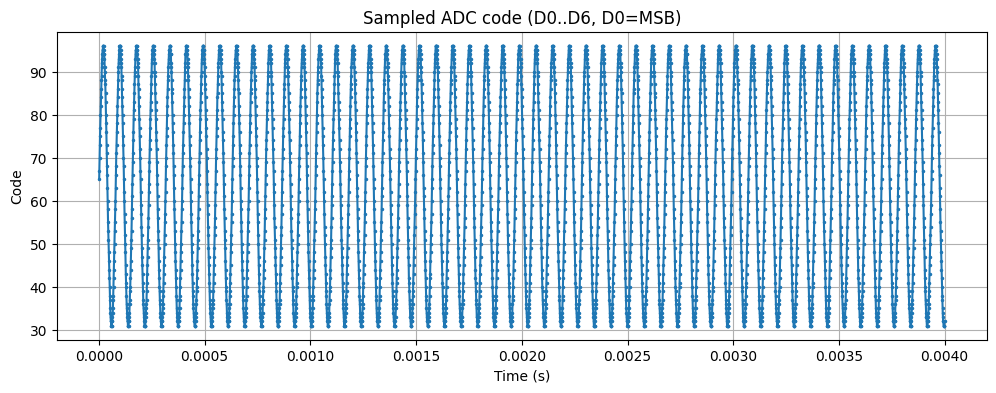

/home/cass/conda-env/envs/ihp/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


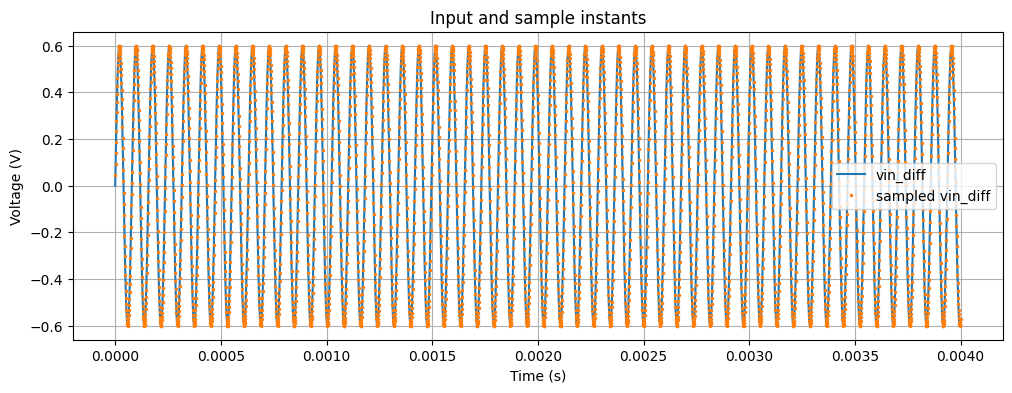

In [6]:
# Quick sanity plots
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_s['time'], df_s['code'], '.-', ms=3)
ax.set_title('Sampled ADC code (D0..D6, D0=MSB)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Code')
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['time'], df['vin_diff'], label='vin_diff')
ax.plot(df_s['time'], df_s['vin_diff'], '.', ms=3, label='sampled vin_diff')
ax.set_title('Input and sample instants')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.grid(True)
ax.legend()
plt.show()

In [7]:
# ENOB / SINAD estimation from sampled codes
discard = 20   # remove startup transient conversions
if len(df_s) <= discard + 64:
    raise ValueError("Too few sampled conversions after discard.")

codes_all = df_s['code'].to_numpy(dtype=float)
times_all = df_s['time'].to_numpy(dtype=float)

codes = codes_all[discard:]
times = times_all[discard:]

# Use a power-of-two FFT length
N = 2 ** int(np.floor(np.log2(len(codes))))
codes = codes[:N]
times = times[:N]

# Estimate sample rate from dac_clk spacing
Ts = np.mean(np.diff(times))
fs = 1.0 / Ts

# Remove DC and apply a Blackman window for non-coherent input tone
x = codes - np.mean(codes)
w = np.blackman(N)
xw = x * w

X = np.fft.rfft(xw)
P = np.abs(X) ** 2
P[0] = 0.0

fund_bin = np.argmax(P)
sig_bins = np.arange(max(1, fund_bin - 2), min(len(P), fund_bin + 3))
signal_power = np.sum(P[sig_bins])

mask = np.ones(len(P), dtype=bool)
mask[0] = False
mask[sig_bins] = False
noise_dist_power = np.sum(P[mask])

sinad = 10 * np.log10(signal_power / noise_dist_power)
enob = (sinad - 1.76) / 6.02
fin = fund_bin * fs / N

print(f"number of ADC samples = {len(df_s)}")
print(f"N used for FFT = {N}")
print(f"fs = {fs:.6f} Hz")
print(f"fund_bin = {fund_bin}")
print(f"fin ≈ {fin:.2f} Hz")
print(f"SINAD = {sinad:.2f} dB")
print(f"ENOB = {enob:.2f} bits")

number of ADC samples = 4000
N used for FFT = 2048
fs = 999999.998534 Hz
fund_bin = 26
fin ≈ 12695.31 Hz
SINAD = 38.03 dB
ENOB = 6.03 bits


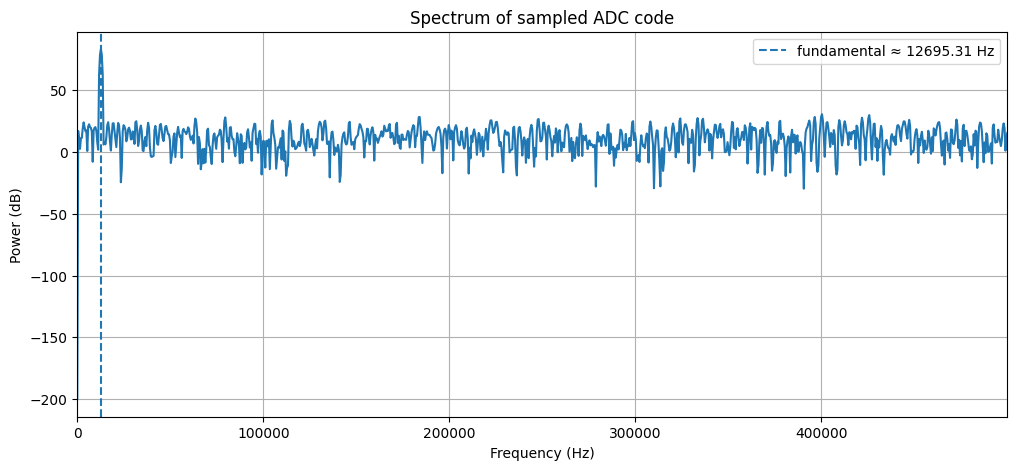

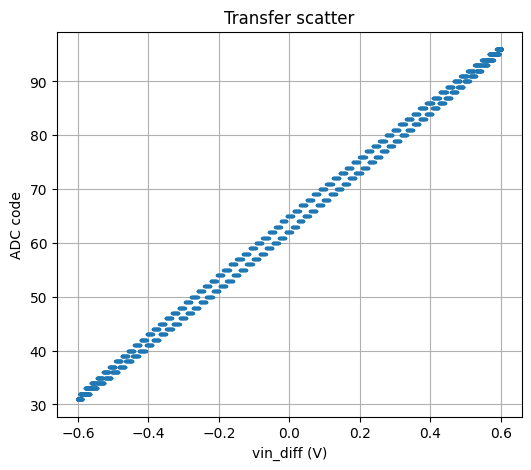

In [8]:
# Spectrum and transfer plots
freq = np.fft.rfftfreq(N, d=Ts)
P_db = 10 * np.log10(np.maximum(P, 1e-20))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(freq, P_db)
ax.axvline(fin, linestyle='--', label=f'fundamental ≈ {fin:.2f} Hz')
ax.set_title('Spectrum of sampled ADC code')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_xlim(0, fs/2)
ax.grid(True)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(df_s['vin_diff'], df_s['code'], '.', ms=3)
ax.set_title('Transfer scatter')
ax.set_xlabel('vin_diff (V)')
ax.set_ylabel('ADC code')
ax.grid(True)
plt.show()